In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv(r"/content/placementdata.csv")
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


In [ ]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [ ]:
df.drop(columns=['StudentID'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       10000 non-null  float64
 1   Internships                10000 non-null  int64  
 2   Projects                   10000 non-null  int64  
 3   Workshops/Certifications   10000 non-null  int64  
 4   AptitudeTestScore          10000 non-null  int64  
 5   SoftSkillsRating           10000 non-null  float64
 6   ExtracurricularActivities  10000 non-null  object 
 7   PlacementTraining          10000 non-null  object 
 8   SSC_Marks                  10000 non-null  int64  
 9   HSC_Marks                  10000 non-null  int64  
 10  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [ ]:
df.isna().sum()

,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0
HSC_Marks,0


In [ ]:
df.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [ ]:
df.duplicated().sum()

np.int64(72)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

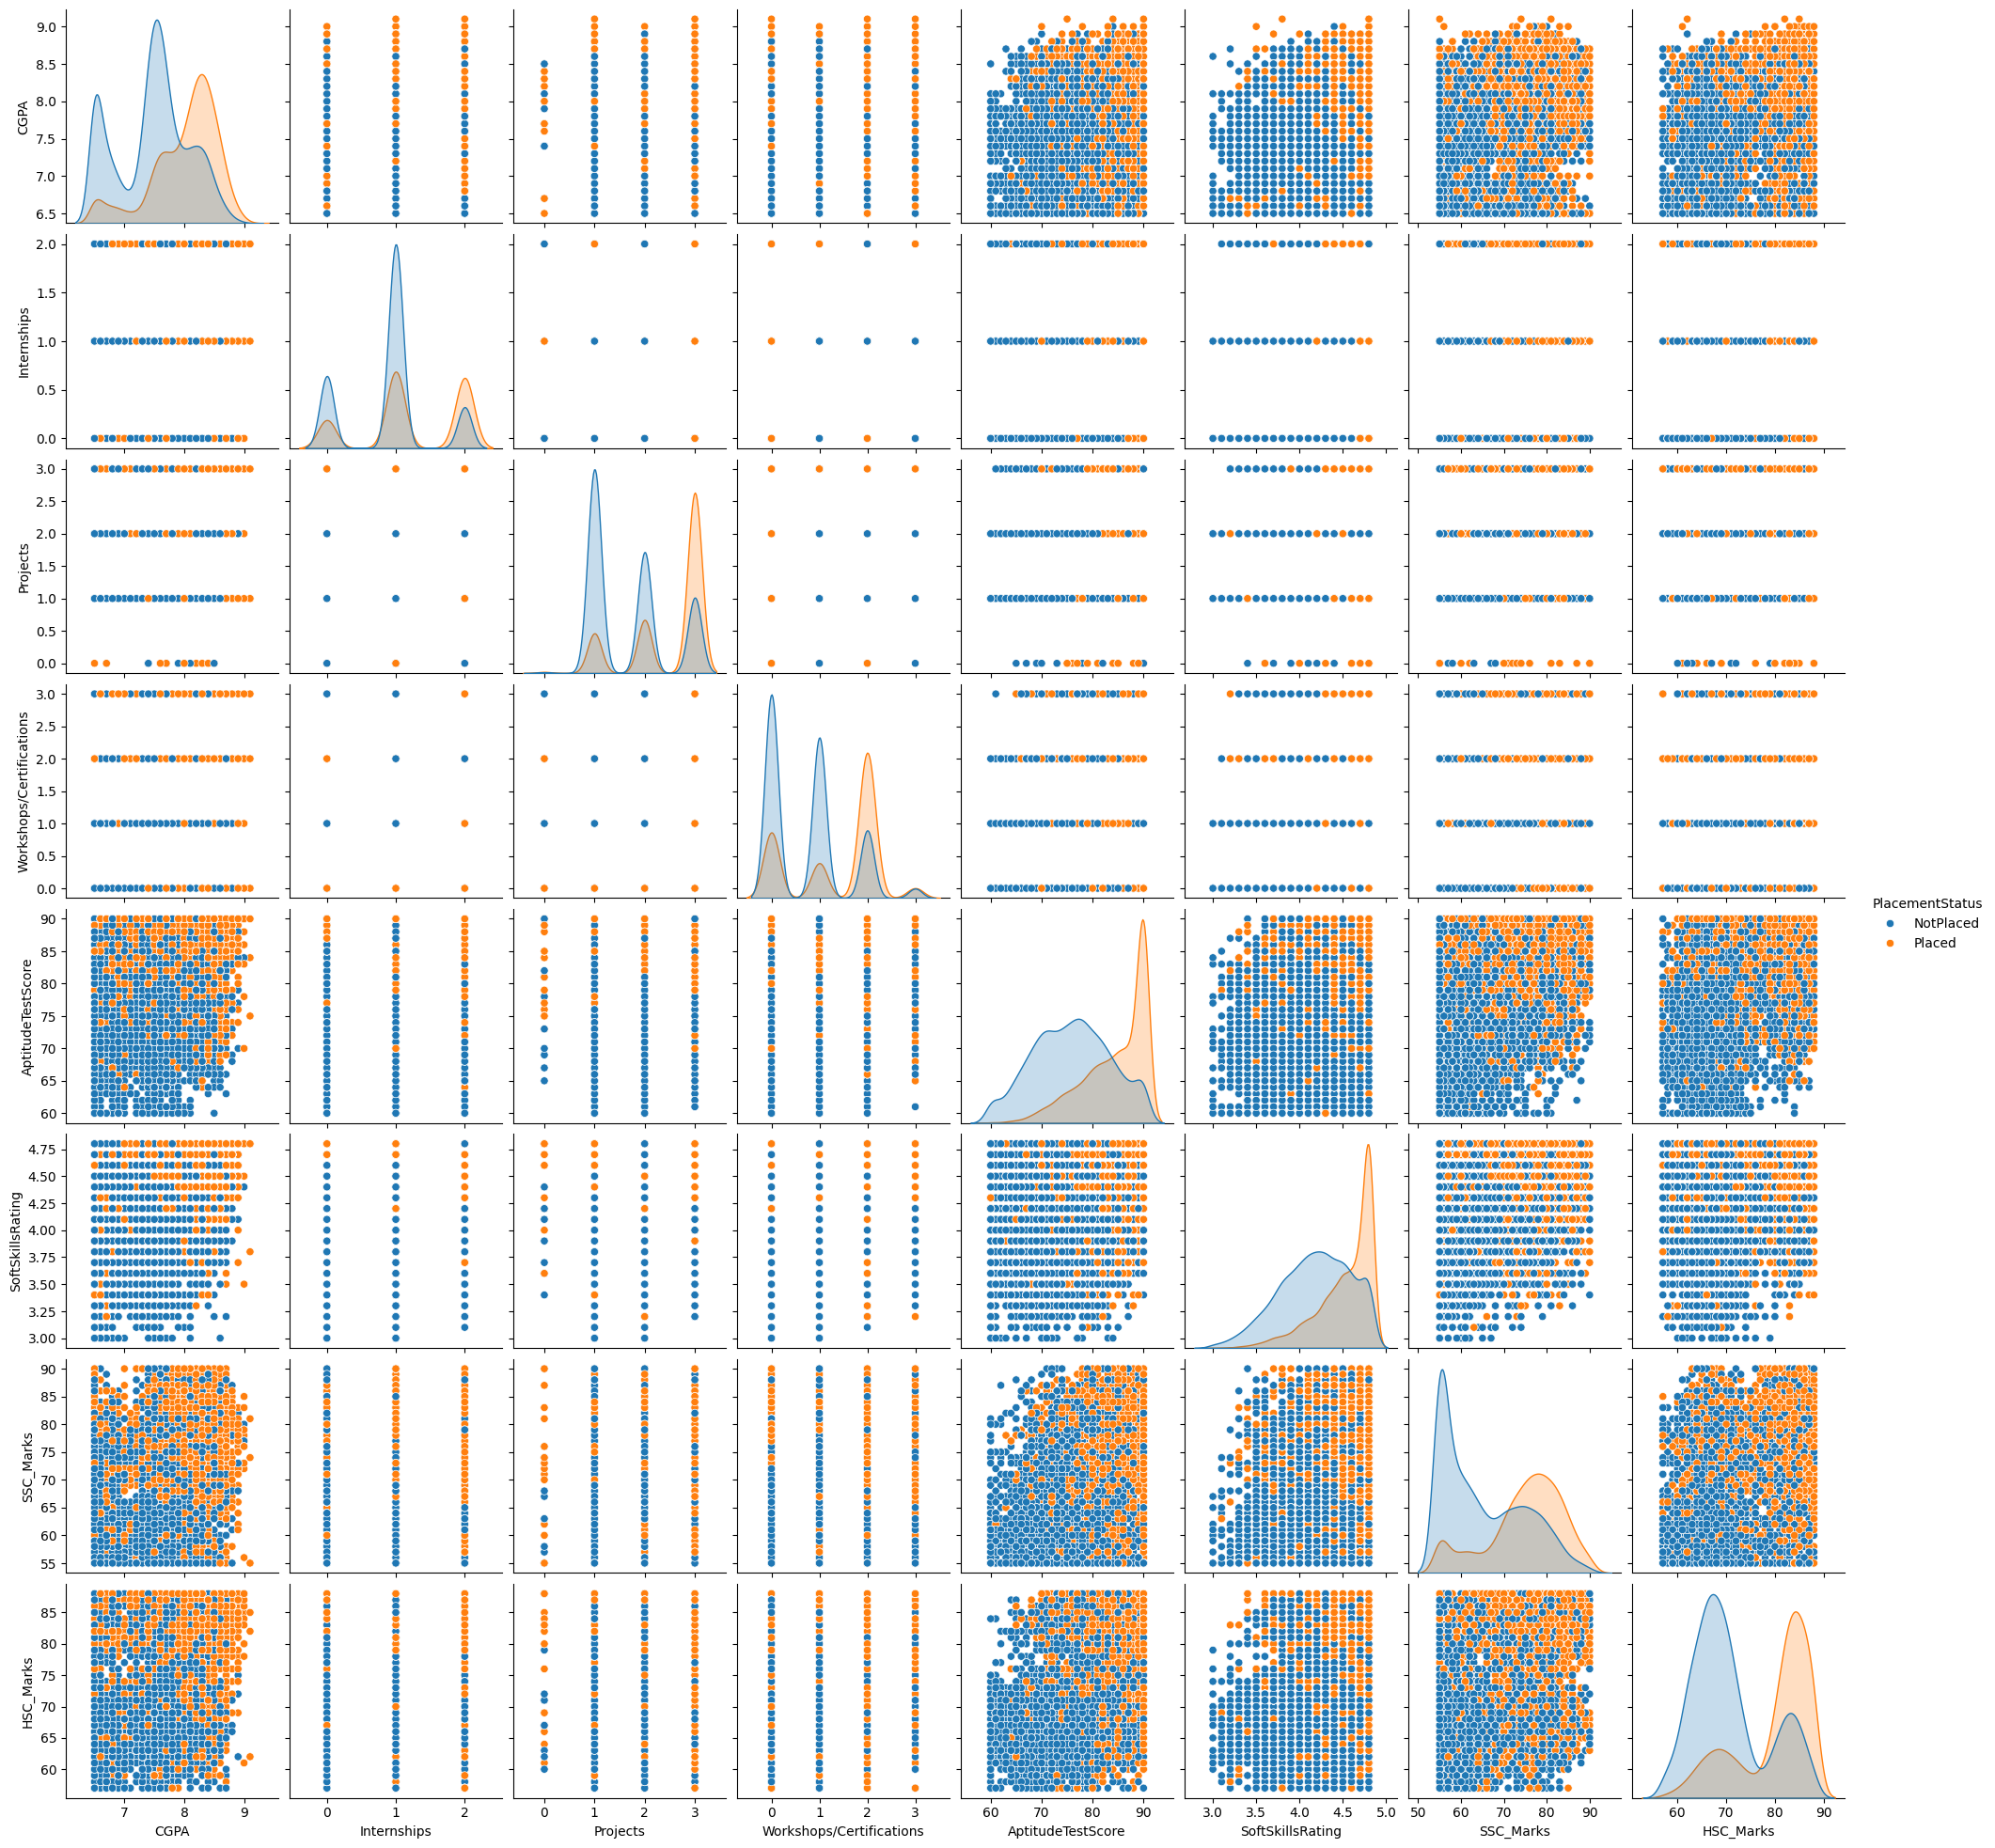

In [ ]:
sns.pairplot(df, hue='PlacementStatus', diag_kind='kde')

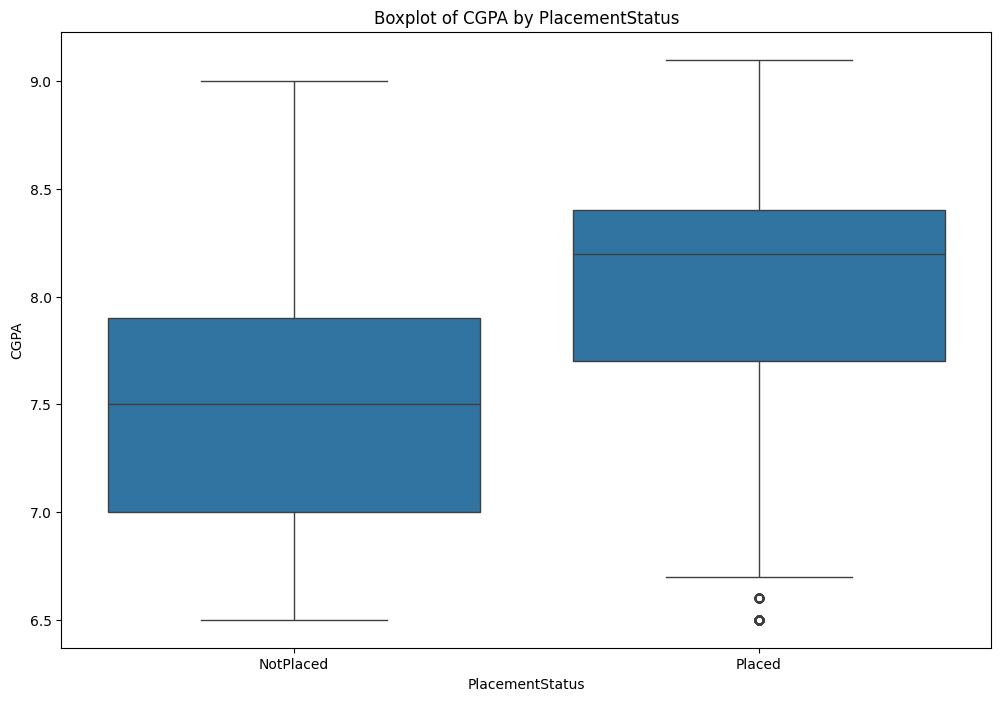

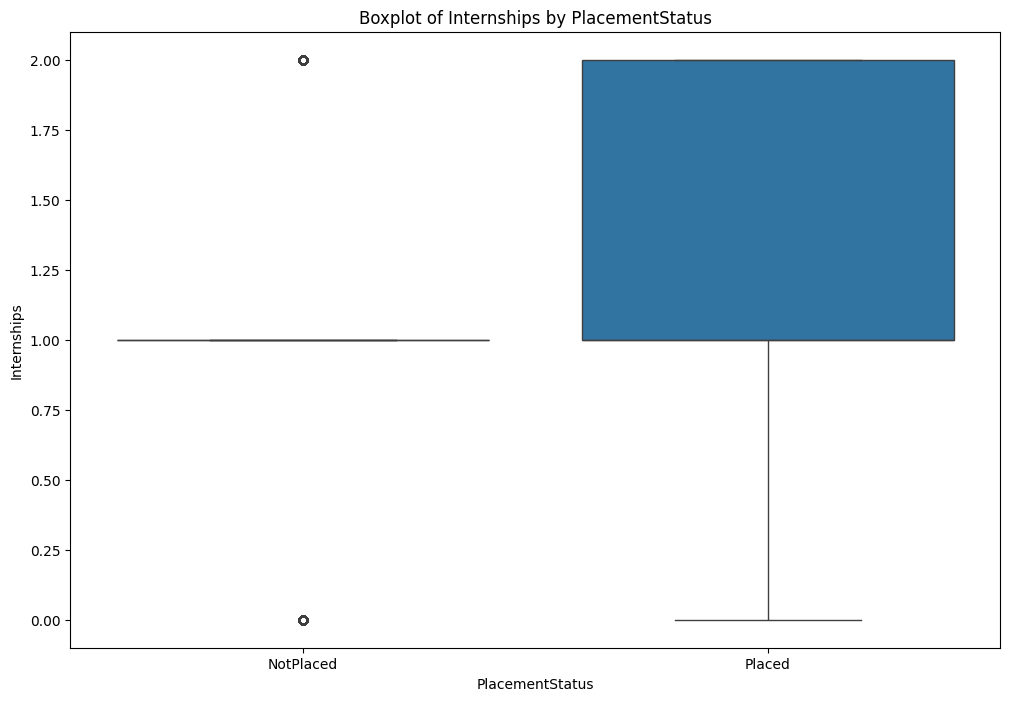

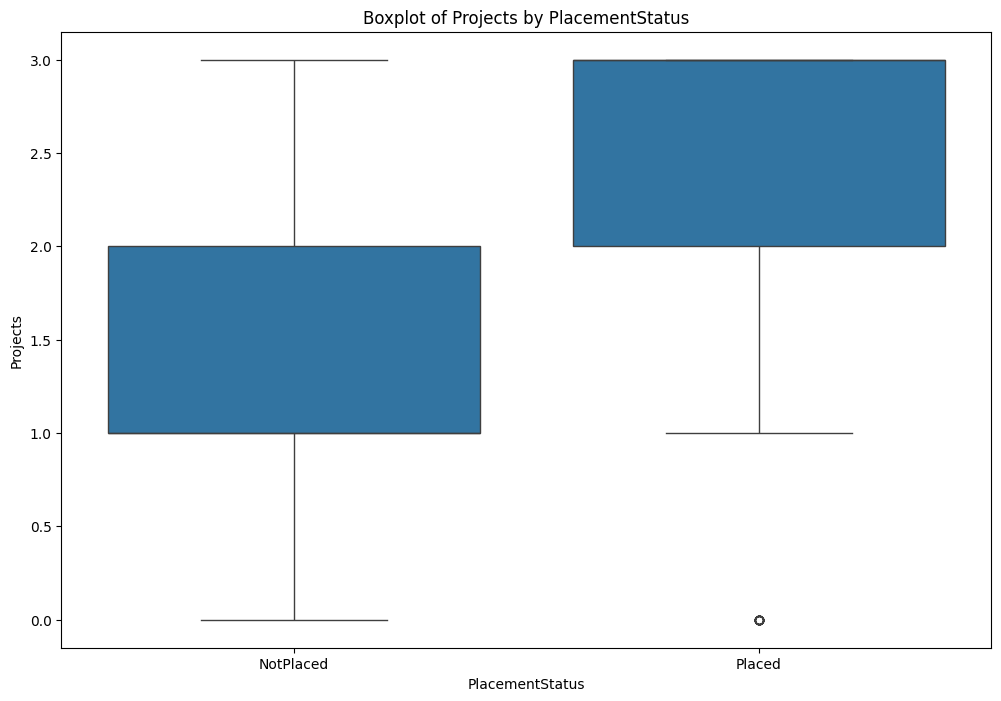

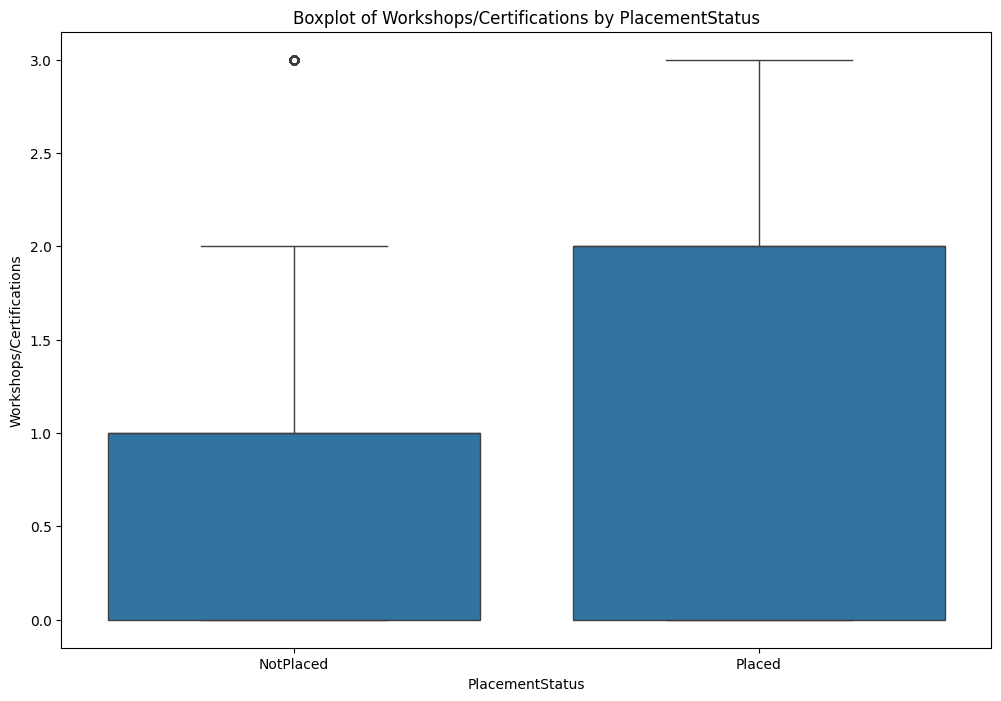

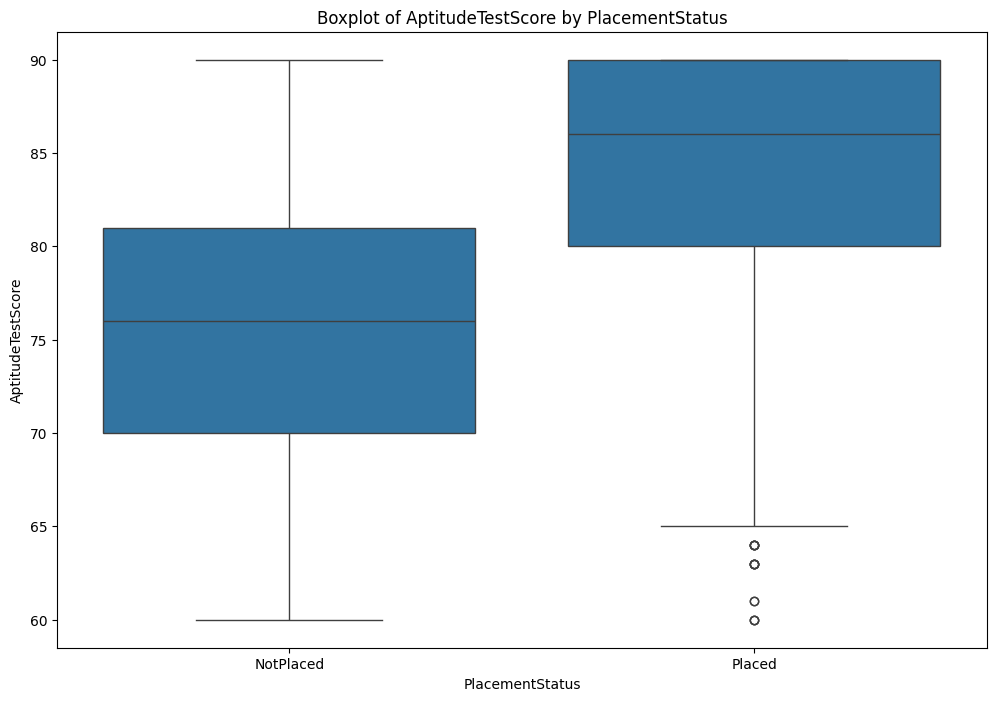

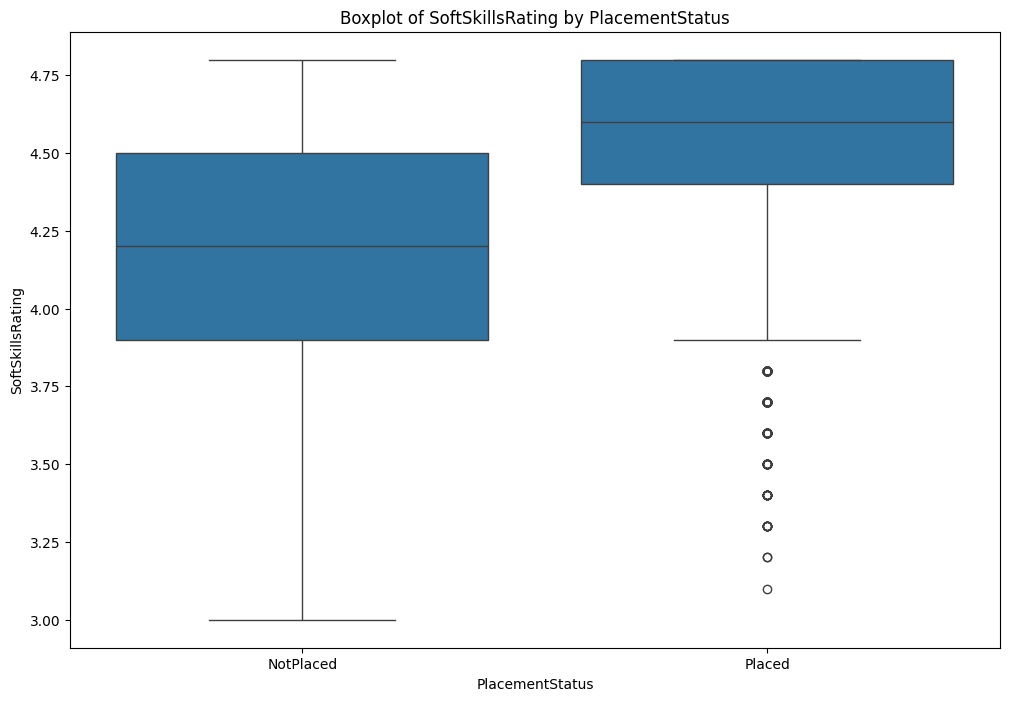

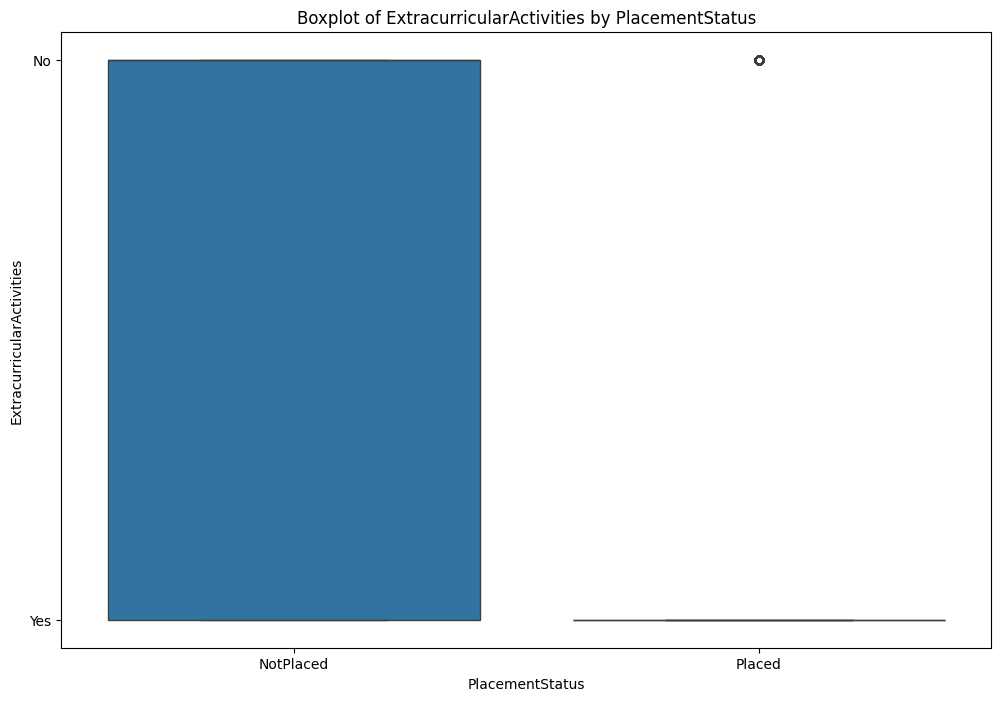

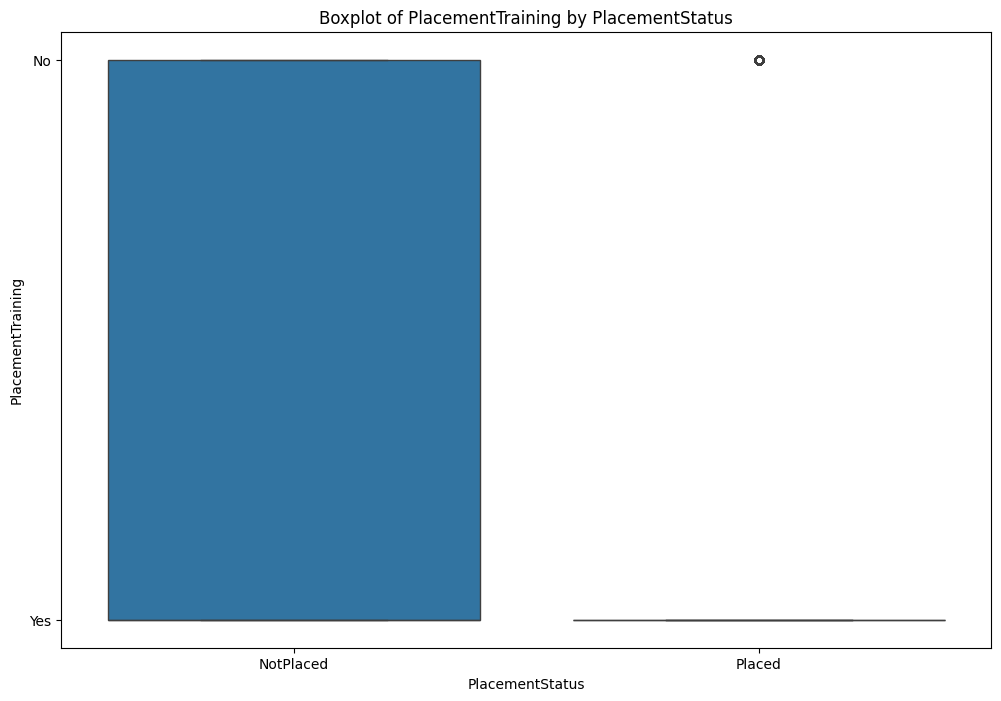

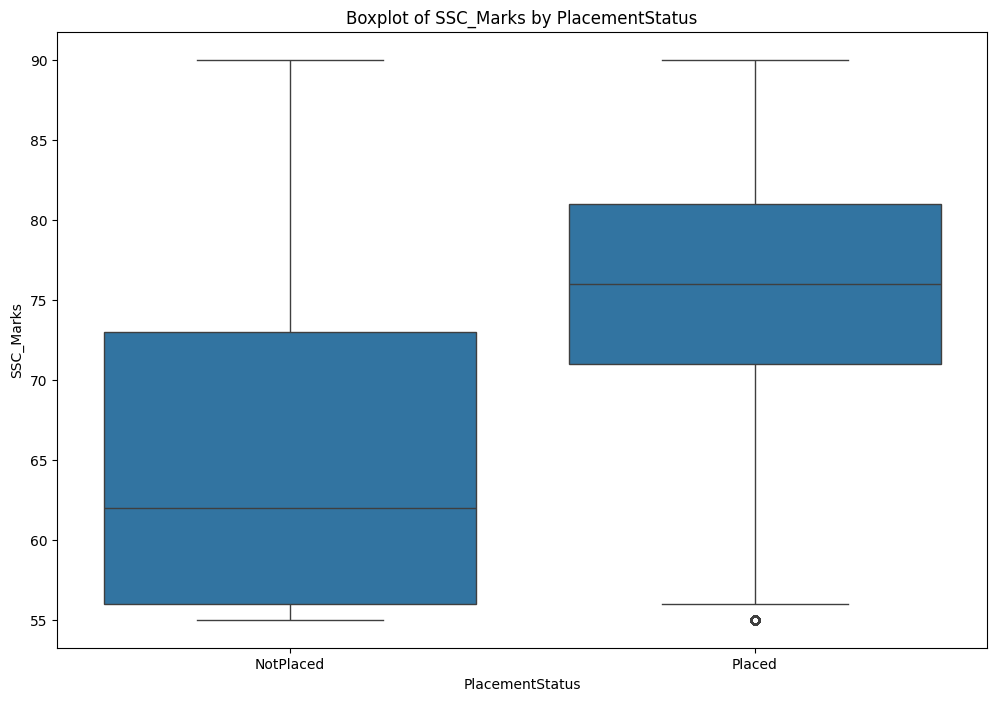

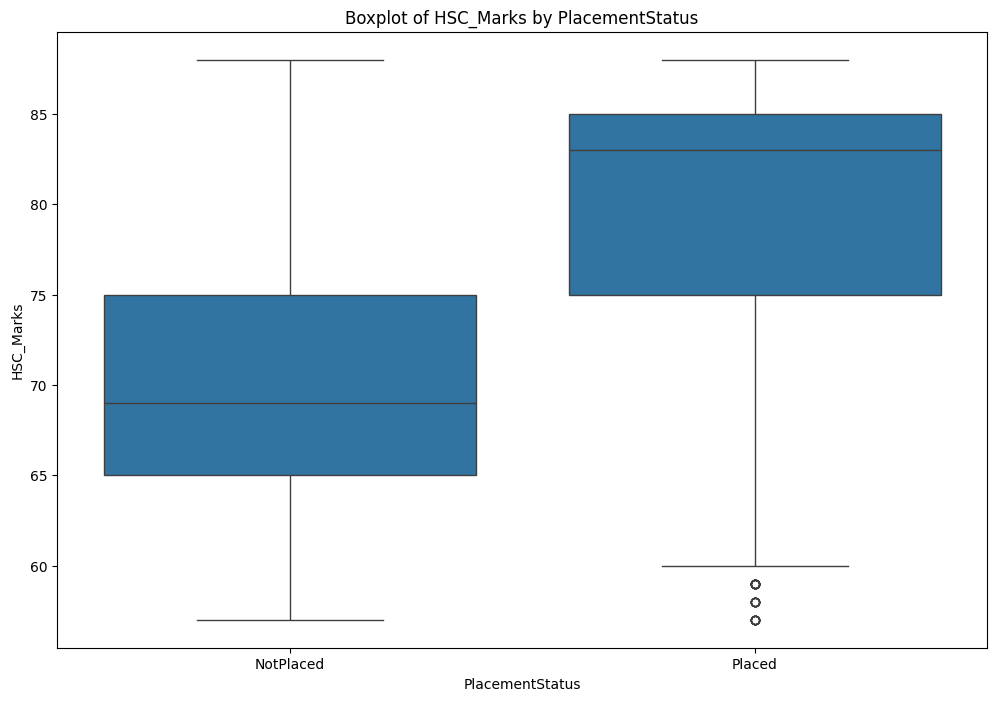

In [ ]:
for i in df.columns:
    if i != 'PlacementStatus':
        plt.figure(figsize=(12, 8))
        plt.title(f'Boxplot of {i} by PlacementStatus')
        sns.boxplot(x='PlacementStatus', y=i, data=df)
        plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['ExtracurricularActivities'])
df['ExtracurricularActivities'] = le.transform(df['ExtracurricularActivities'])

/tmp/ipython-input-13-1356828198.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ExtracurricularActivities'] = le.transform(df['ExtracurricularActivities'])


In [ ]:
le.fit(df['PlacementTraining'])
df['PlacementTraining'] = le.transform(df['PlacementTraining'])
le.fit(df['PlacementStatus'])
df['PlacementStatus'] = le.transform(df['PlacementStatus'])
df

/tmp/ipython-input-14-2481535929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PlacementTraining'] = le.transform(df['PlacementTraining'])
/tmp/ipython-input-14-2481535929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PlacementStatus'] = le.transform(df['PlacementStatus'])


,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66,0
9996,7.4,0,1,0,90,4.8,0,0,84,67,1
9997,8.4,1,3,0,70,4.8,1,1,79,81,1
9998,8.9,0,3,2,87,4.8,1,1,71,85,1


In [ ]:
df.skew()

,0
CGPA,-0.393439
Internships,-0.047337
Projects,-0.066244
Workshops/Certifications,0.219240
AptitudeTestScore,-0.348249
SoftSkillsRating,-0.669849
ExtracurricularActivities,-0.335031
PlacementTraining,-1.035459
SSC_Marks,0.045879
HSC_Marks,0.010067


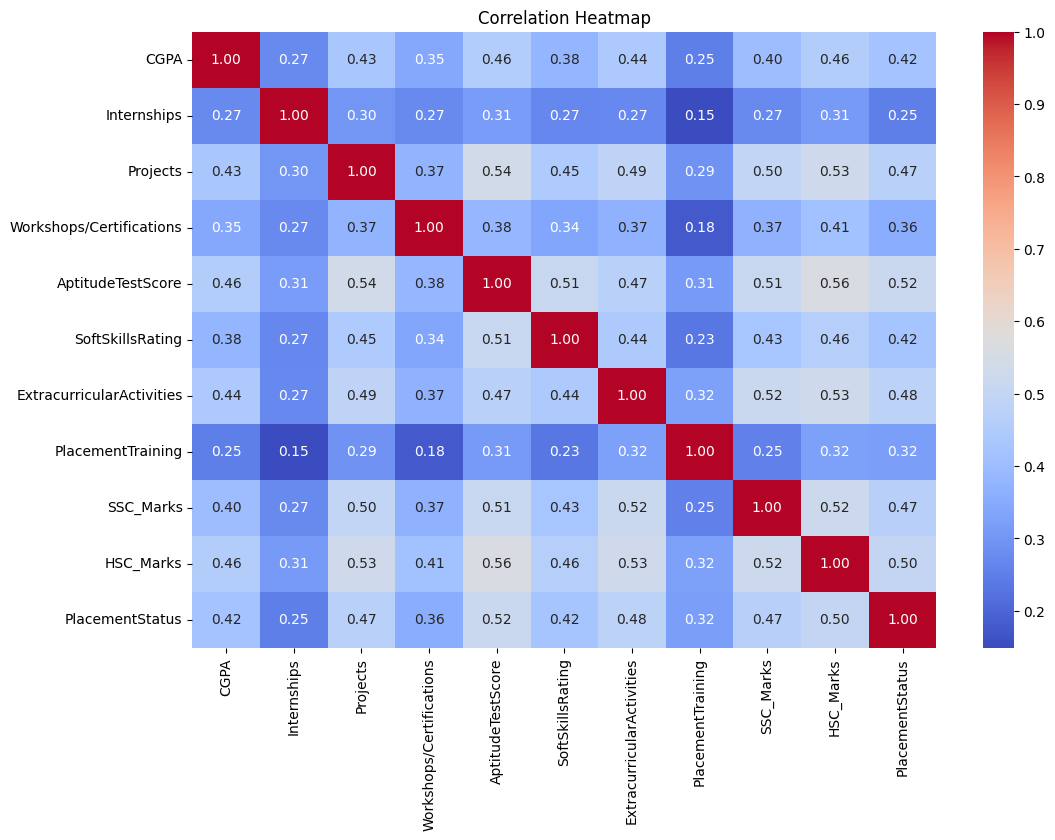

In [ ]:
df_corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
x=df.drop(columns=['PlacementStatus'])
y=df['PlacementStatus']

In [ ]:
x

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,7.5,1,1,1,65,4.4,0,0,61,79
1,8.9,0,3,2,90,4.0,1,1,78,82
2,7.3,1,2,2,82,4.8,1,0,79,80
3,7.5,1,1,2,85,4.4,1,1,81,80
4,8.3,1,2,2,86,4.5,1,1,74,88
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66
9996,7.4,0,1,0,90,4.8,0,0,84,67
9997,8.4,1,3,0,70,4.8,1,1,79,81
9998,8.9,0,3,2,87,4.8,1,1,71,85


In [ ]:
y.value_counts()

,count
PlacementStatus,
0,5801
1,4127


In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x, y = smote.fit_resample(x, y)

In [ ]:
y.value_counts()

,count
PlacementStatus,
0,5801
1,5801


In [ ]:
from sklearn.preprocessing import RobustScaler
sc = RobustScaler()
sc.fit(x)
x_scaled = sc.transform(x)
x_scaled

array([[-0.33806085,  0.        , -0.5       , ..., -1.        ,
        -0.55      ,  0.23529412],
       [ 1.23955644, -1.        ,  0.5       , ...,  0.        ,
         0.3       ,  0.41176471],
       [-0.56343474,  0.        ,  0.        , ..., -1.        ,
         0.35      ,  0.29411765],
       ...,
       [ 0.65357645,  1.        ,  0.5       , ...,  0.        ,
         0.2       ,  0.70588235],
       [ 0.73404212,  1.        ,  0.5       , ...,  0.        ,
        -0.65      ,  0.52941176],
       [ 0.7044402 , -1.        ,  0.5       , ...,  0.        ,
         0.35      ,  0.41176471]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=16)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%--{i}")

Accuracy: 80.57%--PlacementStatus


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=16)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='elasticnet',l1_ratio=1, solver='saga', random_state=100)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%--{i}")


Accuracy: 80.61%--PlacementStatus


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=4)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=93)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%--{i}")

Accuracy: 81.00%--PlacementStatus


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(criterion='gini',max_features='sqrt', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.96%


In [ ]:
pip install xgboost

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 81.00%


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=16)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='elasticnet',l1_ratio=1, solver='saga', random_state=100)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%--{i}")
import pandas as pd
cGPA = float(input("Enter CGPA: "))
Internships= int(input("Enter number of internships: "))
Projects    = int(input("Enter number of projects : "))
Workshops = int(input("Enter number of workshops/certifications: "))
AptitudeTestScore = int(input("Enter Aptitude Test Score: "))
SoftSkillsRating = float(input("Enter Soft Skills Rating: "))
ExtracurricularActivities = int(input("Enter of extracurricular activities(1:yes , 0:no): "))
PlacementTraining = int(input("Enter Placement Training Score(1:yes , 0:no): " ))
sSC_Marks = int(input("Enter SSC Marks: "))
hSC_Marks = int(input("Enter HSC Marks: "))
y={"CGPA":cGPA, "Internships": Internships, "Projects": Projects,
   "Workshops/Certifications":Workshops , "AptitudeTestScore": AptitudeTestScore,
   "SoftSkillsRating": SoftSkillsRating, "ExtracurricularActivities": ExtracurricularActivities,
   "PlacementTraining": PlacementTraining, "SSC_Marks": sSC_Marks, "HSC_Marks": hSC_Marks}
df=pd.DataFrame([y])
print(df)
y_pred = model.predict(sc.transform(df))
y_pred
if y_pred[0] == 1:
    print("Candidate is likely to be placed.")
else:
    print("Candidate is unlikely to be placed.")



Accuracy: 80.61%--PlacementStatus
Enter CGPA: 8.3
Enter number of internships: 2
Enter number of projects : 2
Enter number of workshops/certifications: 10
Enter Aptitude Test Score: 85
Enter Soft Skills Rating: 90
Enter of extracurricular activities(1:yes , 0:no): 1
Enter Placement Training Score(1:yes , 0:no): 1
Enter SSC Marks: 65
Enter HSC Marks: 65
   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0   8.3            2         2                        10                 85   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0              90.0                          1                  1         65   

   HSC_Marks  
0         65  
Candidate is likely to be placed.
